# Reference Wavefront: FAM Study v1

**Author:** Aaron Roodman  
**Date Created:** 2026-02-23  
**Last Modified:** 2026-02-23  
**Status:** [In Progress]  
**Keywords:** [AOS, Intrinsic Wavefront, Full Array Mode, Analysis]

## Description

This notebook analyzes the FAM Zernike table created by `reference_wavefront__FAM_mktable.ipynb`.

**Analysis includes:**
1. Load parquet file with Zernike measurements
2. Analyze data vs model residuals
3. Create visualizations and plots

**Input:** Parquet file created by mktable notebook

## Table of Contents

- [Setup & Imports](#setup)
- [Load Data](#load)
- [Initial Analysis](#analysis)
- [Visualizations](#viz)

<a id='setup'></a>
## Setup & Imports

In [1]:
# Standard imports
from matplotlib import pyplot as plt
from matplotlib import lines
from mpl_toolkits import axes_grid1
from matplotlib.colors import LinearSegmentedColormap

import numpy as np
import pandas as pd
from scipy.stats import binned_statistic_2d, binned_statistic
from pathlib import Path

# Astropy
from astropy.table import Table, QTable

# Set plot defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Pandas display options
pd.options.display.max_columns = None
pd.options.display.width = None

<a id='load'></a>
## Load Data

In [2]:
# Specify the parquet file to analyze
# Update these dates to match your data
day_obs_min = 20250801
day_obs_max = 20251028
parquet_file = f'fam_zernikes_{day_obs_min}_{day_obs_max}.parquet'

# Check if file exists
if not Path(parquet_file).exists():
    raise FileNotFoundError(f"Parquet file not found: {parquet_file}\n" 
                           f"Run reference_wavefront__FAM_mktable.ipynb first to create it.")

print(f"Loading data from: {parquet_file}")
aosTable = QTable.read(parquet_file)
print(f"Loaded {len(aosTable)} rows")
print(f"Columns: {len(aosTable.columns)}")

Loading data from: fam_zernikes_20250801_20251028.parquet
Loaded 448063 rows
Columns: 45


In [3]:
# Display table summary
print("\nTable columns:")
print(sorted(aosTable.columns))

# Count by day_obs
print("\nMeasurements per day_obs:")
day_counts = pd.DataFrame({'day_obs': aosTable['day_obs']}).value_counts().sort_index()
print(day_counts)


Table columns:
['centroid_x', 'centroid_x_extra', 'centroid_x_intra', 'centroid_y', 'centroid_y_extra', 'centroid_y_intra', 'coord_dec', 'coord_dec_extra', 'coord_dec_intra', 'coord_ra', 'coord_ra_extra', 'coord_ra_intra', 'day_obs', 'detector', 'extra_fpx', 'extra_fpy', 'intra_fpx', 'intra_fpy', 'matched_intra_extra', 'seq_num', 'th_N', 'th_N_extra', 'th_N_intra', 'th_W', 'th_W_extra', 'th_W_intra', 'thx_CCS', 'thx_CCS_extra', 'thx_CCS_intra', 'thx_OCS', 'thx_OCS_extra', 'thx_OCS_intra', 'thy_CCS', 'thy_CCS_extra', 'thy_CCS_intra', 'thy_OCS', 'thy_OCS_extra', 'thy_OCS_intra', 'used', 'zk_CCS', 'zk_CCS_mean', 'zk_NW', 'zk_OCS', 'zk_intrinsic', 'zk_residual']

Measurements per day_obs:
day_obs 
20250825    120458
20250826     94567
20250907      1586
20250909      7029
20250912     11256
20250913     52244
20251023     44375
20251024      9162
20251026     79514
20251027     20498
20251028      7374
Name: count, dtype: int64


In [4]:
# Display sample rows with formatted floats
# Select scalar columns only
scalar_cols = []
for col in aosTable.columns:
    if not hasattr(aosTable[col][0], '__len__') or isinstance(aosTable[col][0], str):
        scalar_cols.append(col)

df_display = aosTable[scalar_cols].to_pandas()
pd.options.display.float_format = '{:.2f}'.format

print("\nSample rows (first 5):")
print(df_display.head())

pd.reset_option('display.float_format')


Sample rows (first 5):
  detector  used  coord_ra  coord_dec  centroid_x  centroid_y  thx_CCS  \
0  R01_S00  True      4.72      -0.38     3773.04     3752.49    -0.03   
1  R01_S01  True      4.72      -0.38     1991.94     3338.47    -0.03   
2  R01_S01  True      4.72      -0.38     2997.63     2987.60    -0.03   
3  R01_S01  True      4.72      -0.38     2273.00     2673.47    -0.03   
4  R01_S01  True      4.72      -0.38      988.99     2905.48    -0.03   

   thy_CCS  thx_OCS  thy_OCS  th_N  th_W  coord_ra_intra  coord_ra_extra  \
0    -0.01    -0.03    -0.01  0.03 -0.02            4.72            4.72   
1    -0.01    -0.03    -0.01  0.02 -0.02            4.72            4.72   
2    -0.01    -0.03    -0.01  0.02 -0.02            4.72            4.72   
3    -0.01    -0.03    -0.01  0.02 -0.02            4.72            4.72   
4    -0.01    -0.03    -0.01  0.02 -0.02            4.72            4.72   

   coord_dec_intra  coord_dec_extra  centroid_x_intra  centroid_x_extra  \

<a id='analysis'></a>
## Initial Analysis

In [5]:
def get_zernike(table, column_name, iZ):
    """
    Extract a single Zernike term from an array column.
    
    Parameters
    ----------
    table : QTable
        Table with Zernike array columns
    column_name : str
        Column name ('zk_CCS', 'zk_CCS_mean', 'zk_intrinsic', 'zk_residual')
    iZ : int
        Zernike index (4-28, excluding 20, 21)
    
    Returns
    -------
    array : ndarray
        Zernike values in meters
    
    Examples
    --------
    >>> Z4_data = get_zernike(aosTable, 'zk_CCS', 4)
    >>> Z5_model = get_zernike(aosTable, 'zk_intrinsic', 5)
    >>> Z6_residual = get_zernike(aosTable, 'zk_residual', 6)
    """
    iZs = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]
    iZidx = {iZ_val: i for i, iZ_val in enumerate(iZs)}
    
    if iZ not in iZidx:
        raise ValueError(f"Zernike Z{iZ} not in table. Available: {iZs}")
    
    zk_array = np.stack(table[column_name])
    return zk_array[:, iZidx[iZ]]


# Print reminder about units
print("Helper function 'get_zernike()' loaded.")
print("\nUnits in table:")
print("  - All Zernike values: meters (m)")
print("  - Field angles (thx_CCS, thy_CCS): radians")
print("  - Use np.rad2deg() to convert to degrees for plotting")

Helper function 'get_zernike()' loaded.

Units in table:
  - All Zernike values: meters (m)
  - Field angles (thx_CCS, thy_CCS): radians
  - Use np.rad2deg() to convert to degrees for plotting


In [6]:
# Define Zernike indices
iZs = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]
iZidx = {iZ: i for i, iZ in enumerate(iZs)}

# Extract Zernike arrays
zk_data = np.stack(aosTable['zk_CCS'])
zk_model = np.stack(aosTable['zk_intrinsic'])
zk_residual = np.stack(aosTable['zk_residual'])

print(f"Extracted Zernike arrays:")
print(f"  Shape: {zk_data.shape} (rows x Zernikes)")
print(f"  Zernike indices: {iZs}")

Extracted Zernike arrays:
  Shape: (448063, 21) (rows x Zernikes)
  Zernike indices: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]


<a id='viz'></a>
## Visualizations

Create trio plots for each Zernike term: Data, Model, and Data-Model residuals.

In [7]:
def add_colorbar(im, aspect=20, pad_fraction=0.5, **kwargs):
    """Add a vertical color bar to an image plot."""
    divider = axes_grid1.make_axes_locatable(im.axes)
    width = axes_grid1.axes_size.AxesY(im.axes, aspect=1./aspect)
    pad = axes_grid1.axes_size.Fraction(pad_fraction, width)
    current_ax = plt.gca()
    cax = divider.append_axes("right", size=width, pad=pad)
    plt.sca(current_ax)
    return im.axes.figure.colorbar(im, cax=cax, **kwargs)

In [8]:
# Filter for matched intra/extra donuts
matched_mask = aosTable['matched_intra_extra']
print(f"Total donuts: {len(aosTable)}")
print(f"Matched intra/extra donuts: {np.sum(matched_mask)}")
print(f"Fraction matched: {np.sum(matched_mask)/len(aosTable):.3f}")

# Apply filter
aosTable_matched = aosTable[matched_mask]

Total donuts: 448063
Matched intra/extra donuts: 323608
Fraction matched: 0.722


In [11]:
def plot_zernike_trio(aosTable_matched, iZ, plo=4.0, phi=96.0, output_dir='.'):
    """
    Create trio of plots for a Zernike term: Data, Model, Data-Model.
    
    Parameters
    ----------
    aosTable_matched : QTable
        Table with matched intra/extra donuts
    iZ : int
        Zernike index (e.g., 4 for defocus)
    plo, phi : float
        Percentile limits for colorbar
    output_dir : str
        Directory to save figures
    """
    # Define Zernike indices
    iZs = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]
    iZidx = {iZ_val: i for i, iZ_val in enumerate(iZs)}
    
    # Set up grid for binning
    nsteps = 18 * 4 + 1
    fpradius = 1.8  # degrees
    xbins = np.linspace(-fpradius, fpradius, nsteps)
    ybins = np.linspace(-fpradius, fpradius, nsteps)
    
    # Get field angles in degrees
    xval = np.rad2deg(aosTable_matched['thy_CCS_extra'])
    yval = np.rad2deg(aosTable_matched['thx_CCS_extra'])
    
    # Extract Zernike data
    zk_data_all = np.stack(aosTable_matched['zk_CCS'])
    zk_mean_all = np.stack(aosTable_matched['zk_CCS_mean'])
    zk_model_all = np.stack(aosTable_matched['zk_intrinsic'])
    
    # Get this Zernike term with mean subtracted (for data)
    zval_data = (zk_data_all[:, iZidx[iZ]] - zk_mean_all[:, iZidx[iZ]])
    zval_model = zk_model_all[:, iZidx[iZ]] * 1e6  # Convert meters to microns
    zval_residual = zval_data - zval_model  # Already mean-subtracted and converted to microns
    
    # Create trio of plots
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Plot 1: Data (mean-subtracted)
    mean_val_data, _, _, _ = binned_statistic_2d(
        xval, yval, zval_data,
        statistic='mean',
        bins=[xbins, ybins]
    )
    vmin_data, vmax_data = np.nanpercentile(zval_data, [plo, phi])
    im0 = axes[0].imshow(
        mean_val_data.T, origin='lower',
        extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]],
        cmap='viridis', interpolation='none', aspect='equal',
        vmin=vmin_data, vmax=vmax_data
    )
    add_colorbar(im0, label='μm')
    axes[0].set_xlabel('thy_CCS [deg]')
    axes[0].set_ylabel('thx_CCS [deg]')
    axes[0].set_title(f'Z{iZ} Data (mean per visit subtracted)')
    axes[0].set_aspect('equal')
    
    # Plot 2: Model
    mean_val_model, _, _, _ = binned_statistic_2d(
        xval, yval, zval_model,
        statistic='mean',
        bins=[xbins, ybins]
    )
    vmin_model, vmax_model = np.nanpercentile(zval_model, [plo, phi])
    im1 = axes[1].imshow(
        mean_val_model.T, origin='lower',
        extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]],
        cmap='viridis', interpolation='none', aspect='equal',
        vmin=vmin_model, vmax=vmax_model
    )
    add_colorbar(im1, label='μm')
    axes[1].set_xlabel('thy_CCS [deg]')
    axes[1].set_ylabel('thx_CCS [deg]')
    axes[1].set_title(f'Z{iZ} Model Intrinsic')
    axes[1].set_aspect('equal')
    
    # Plot 3: Data - Model
    mean_val_residual, _, _, _ = binned_statistic_2d(
        xval, yval, zval_residual,
        statistic='mean',
        bins=[xbins, ybins]
    )
    vmin_res, vmax_res = np.nanpercentile(zval_residual, [plo, phi])
    im2 = axes[2].imshow(
        mean_val_residual.T, origin='lower',
        extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]],
        cmap='RdBu_r', interpolation='none', aspect='equal',
        vmin=vmin_res, vmax=vmax_res
    )
    add_colorbar(im2, label='μm')
    axes[2].set_xlabel('thy_CCS [deg]')
    axes[2].set_ylabel('thx_CCS [deg]')
    axes[2].set_title(f'Z{iZ} Data - Model')
    axes[2].set_aspect('equal')
    
    # Overall title
    fig.suptitle(f'Z{iZ} Comparison: Data vs Model (matched In/Ex donuts)', 
                 fontsize=14, y=0.98)
    
    plt.tight_layout()
    
    # Save figure
    output_file = f'{output_dir}/Z{iZ}_trio_comparison.png'
    fig.savefig(output_file, dpi=150, bbox_inches='tight')
    print(f"Saved: {output_file}")
    
    plt.show()
    
    # Print statistics
    print(f"\nZ{iZ} Statistics (μm):")
    print(f"  Data (mean-sub):  mean={np.nanmean(zval_data):7.2f}, std={np.nanstd(zval_data):7.2f}")
    print(f"  Model:            mean={np.nanmean(zval_model):7.2f}, std={np.nanstd(zval_model):7.2f}")
    print(f"  Residual:         mean={np.nanmean(zval_residual):7.2f}, std={np.nanstd(zval_residual):7.2f}")
    print("="*60)

Saved: ./Z4_trio_comparison.png


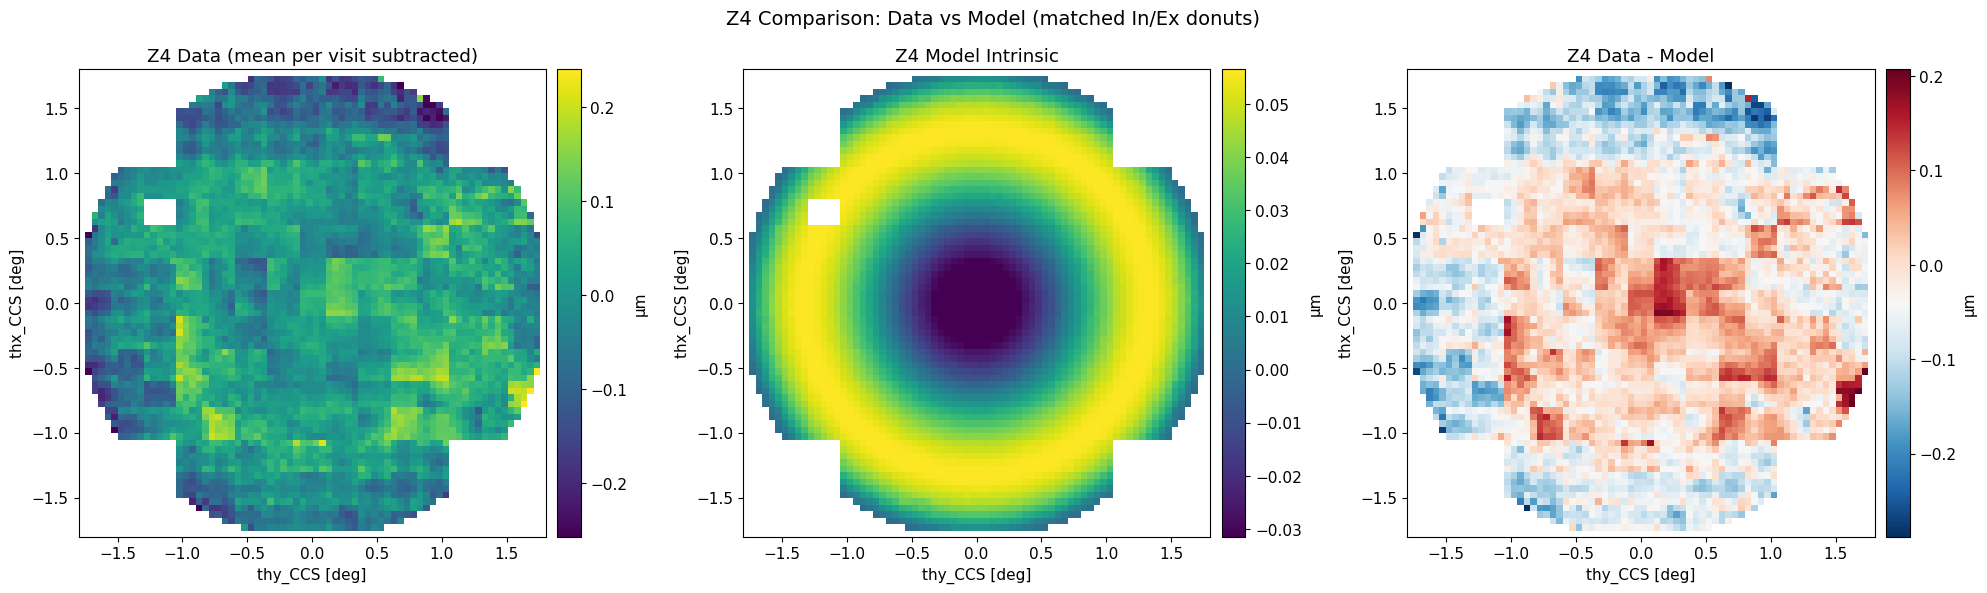


Z4 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.14
  Model:            mean=   0.03, std=   0.03
  Residual:         mean=  -0.03, std=   0.14


In [12]:
# Example: Plot Z4 (defocus)
plot_zernike_trio(aosTable_matched, iZ=4, plo=4.0, phi=96.0, output_dir='.')

Saved: ./Z4_trio_comparison.png


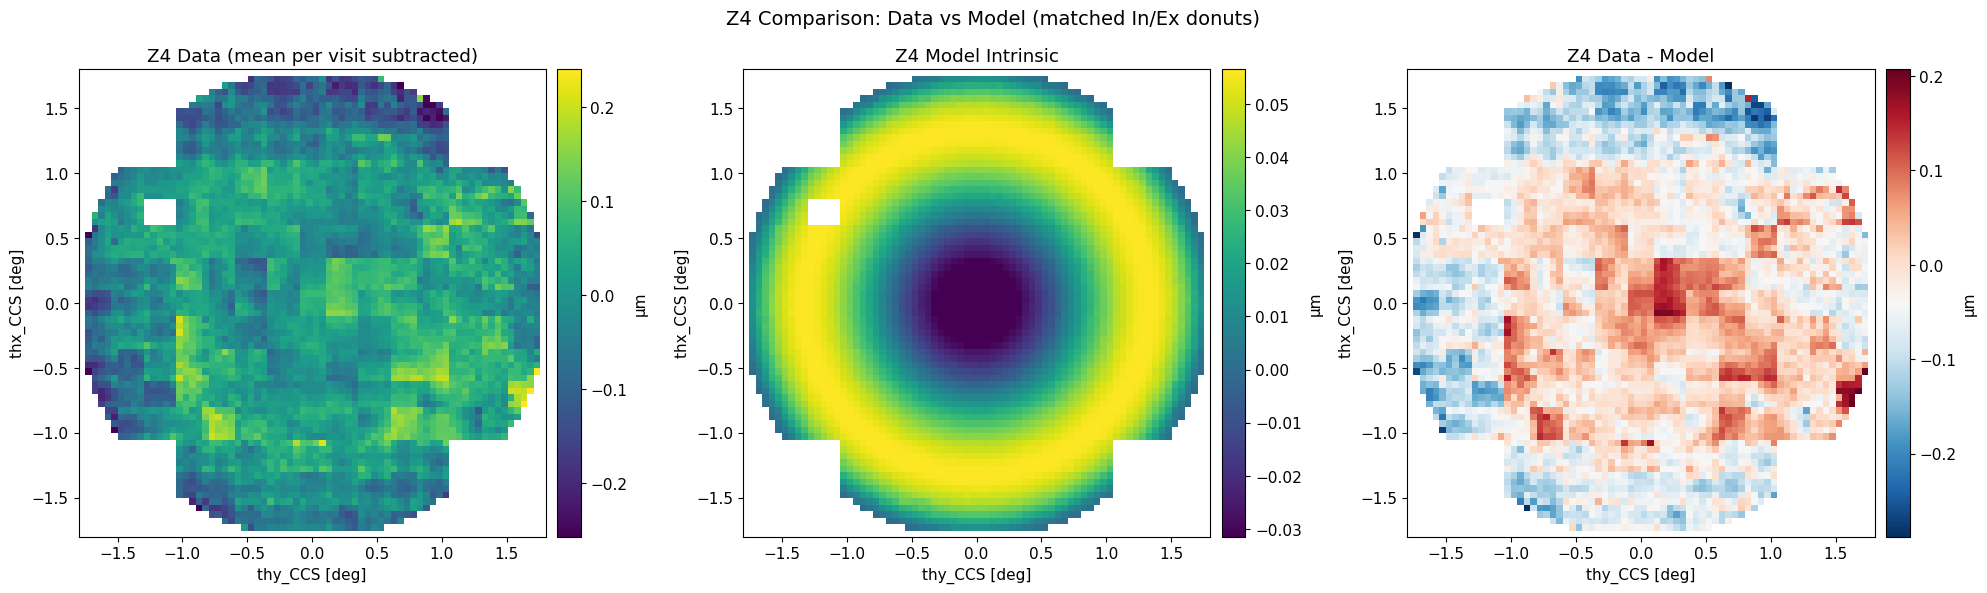


Z4 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.14
  Model:            mean=   0.03, std=   0.03
  Residual:         mean=  -0.03, std=   0.14
Saved: ./Z5_trio_comparison.png


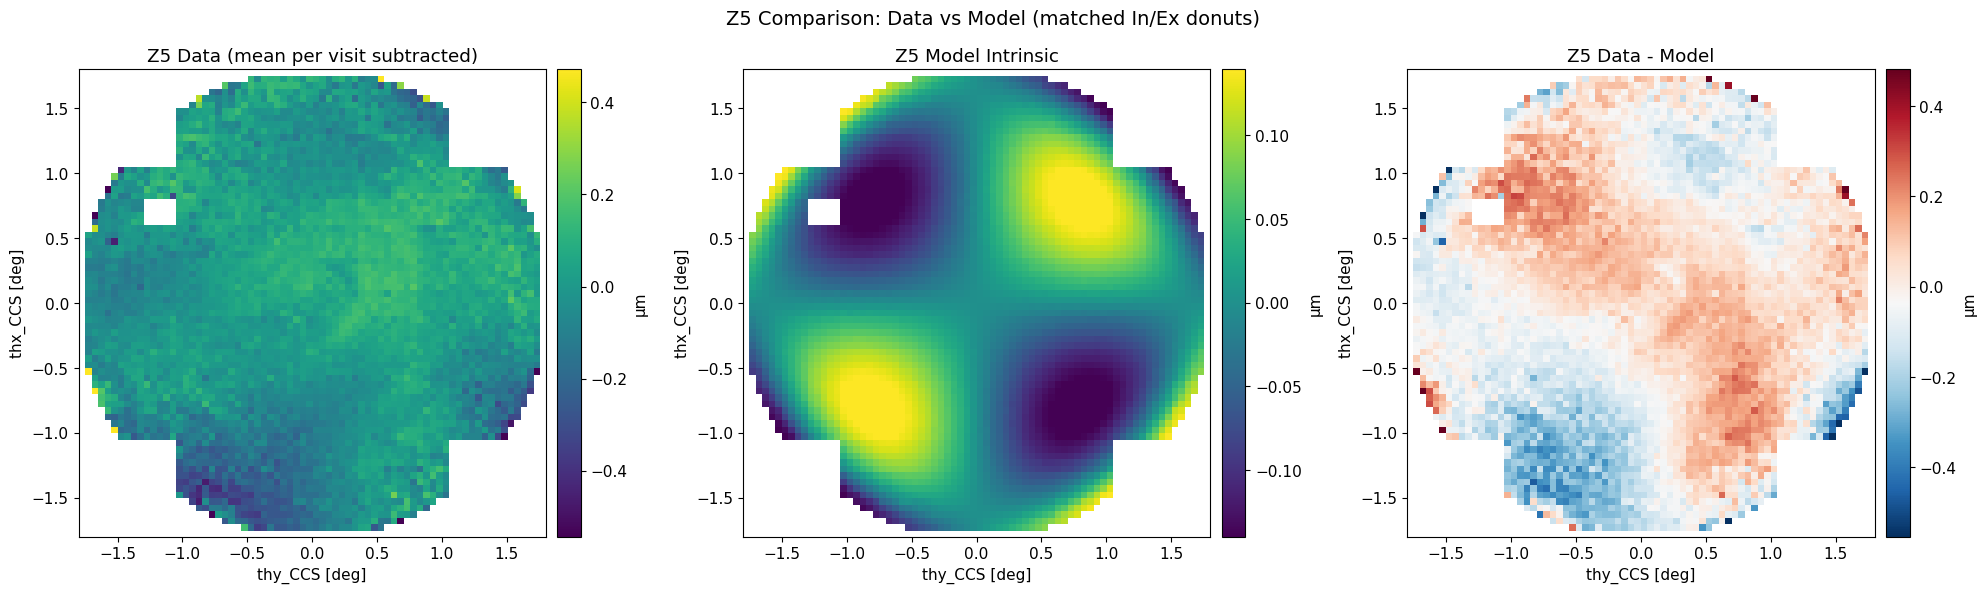


Z5 Statistics (μm):
  Data (mean-sub):  mean=  -0.00, std=   0.29
  Model:            mean=   0.00, std=   0.08
  Residual:         mean=  -0.00, std=   0.30
Saved: ./Z6_trio_comparison.png


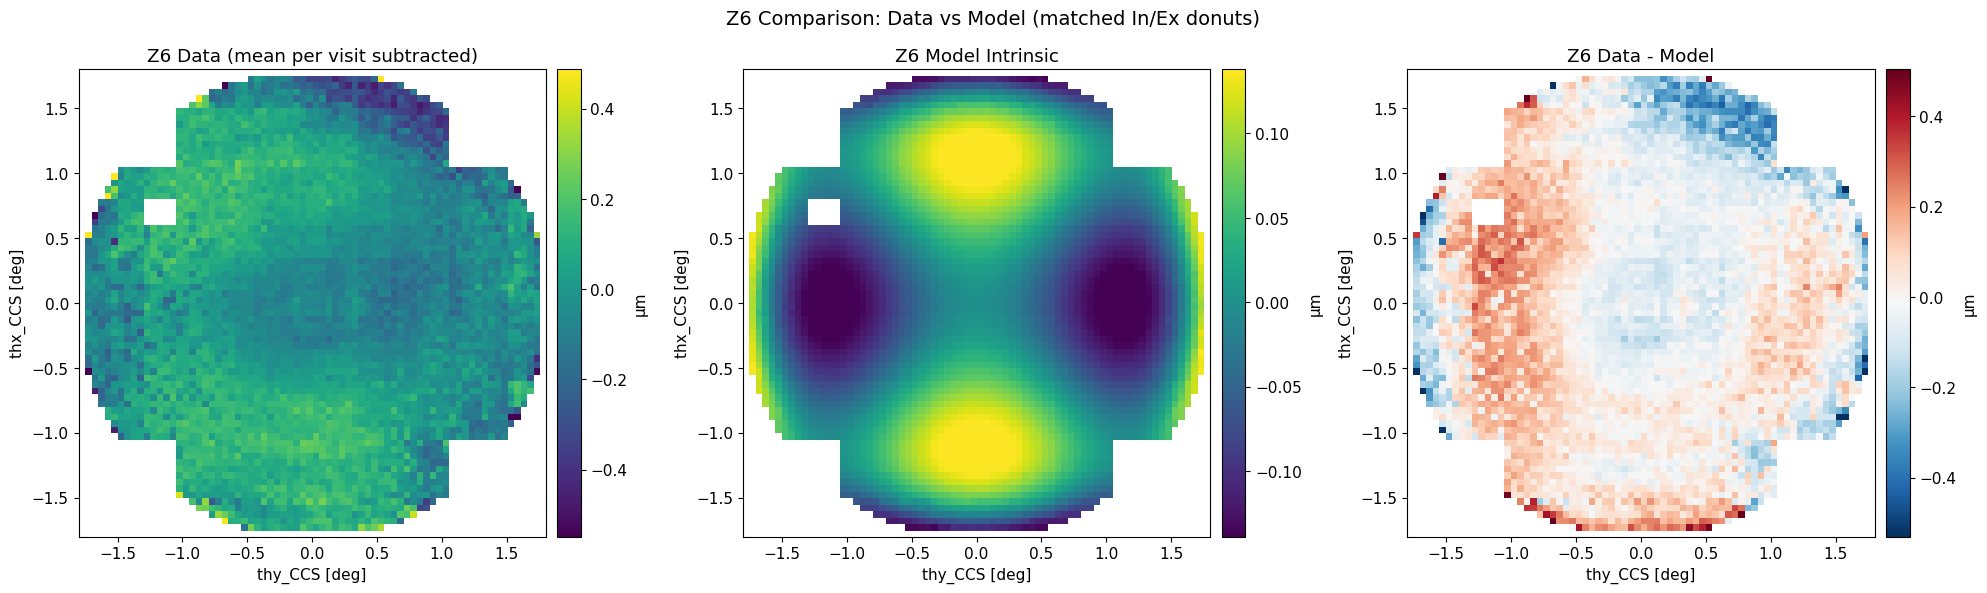


Z6 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.30
  Model:            mean=  -0.00, std=   0.08
  Residual:         mean=   0.00, std=   0.30
Saved: ./Z7_trio_comparison.png


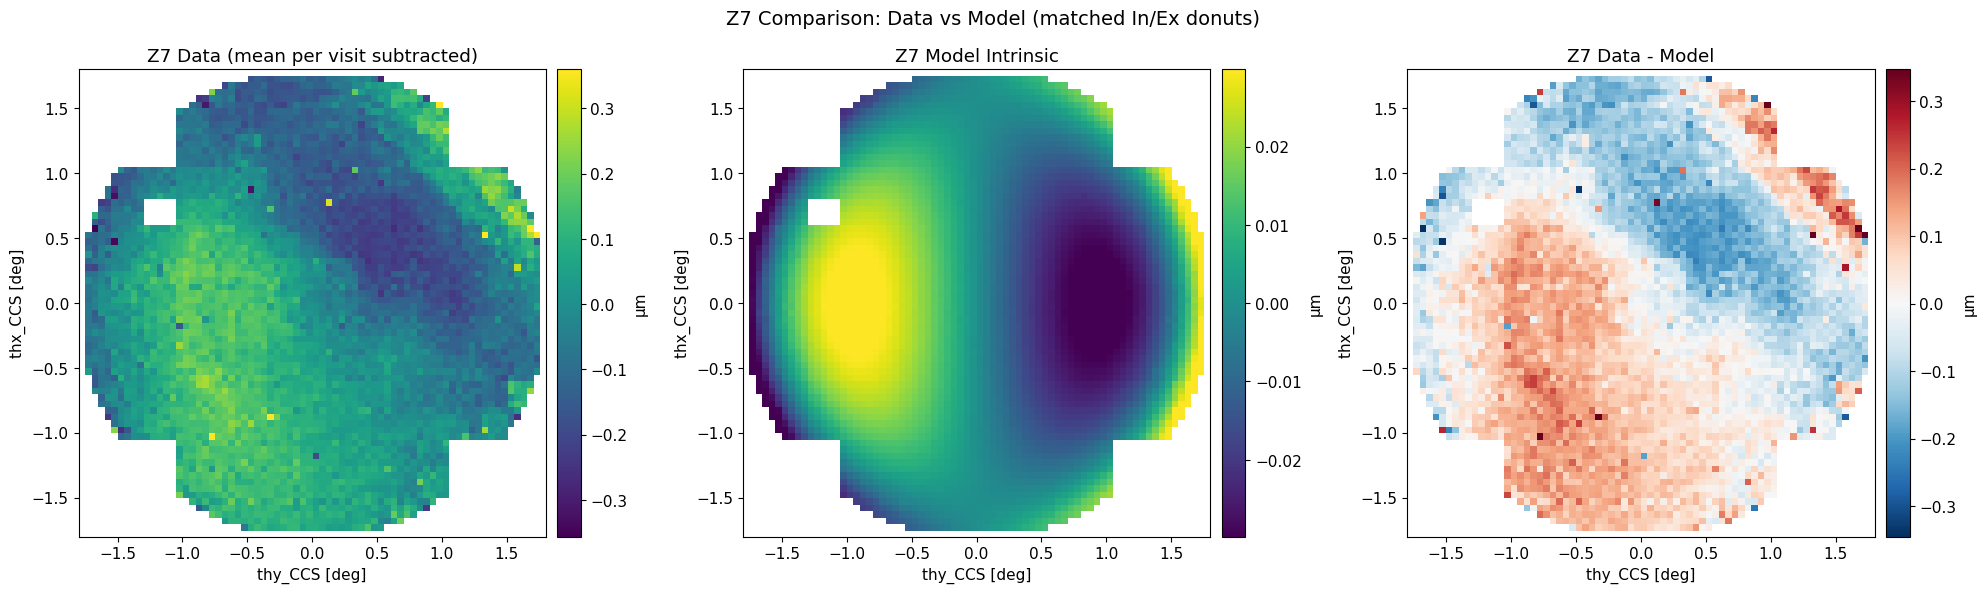


Z7 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.23
  Model:            mean=  -0.00, std=   0.02
  Residual:         mean=   0.00, std=   0.23
Saved: ./Z8_trio_comparison.png


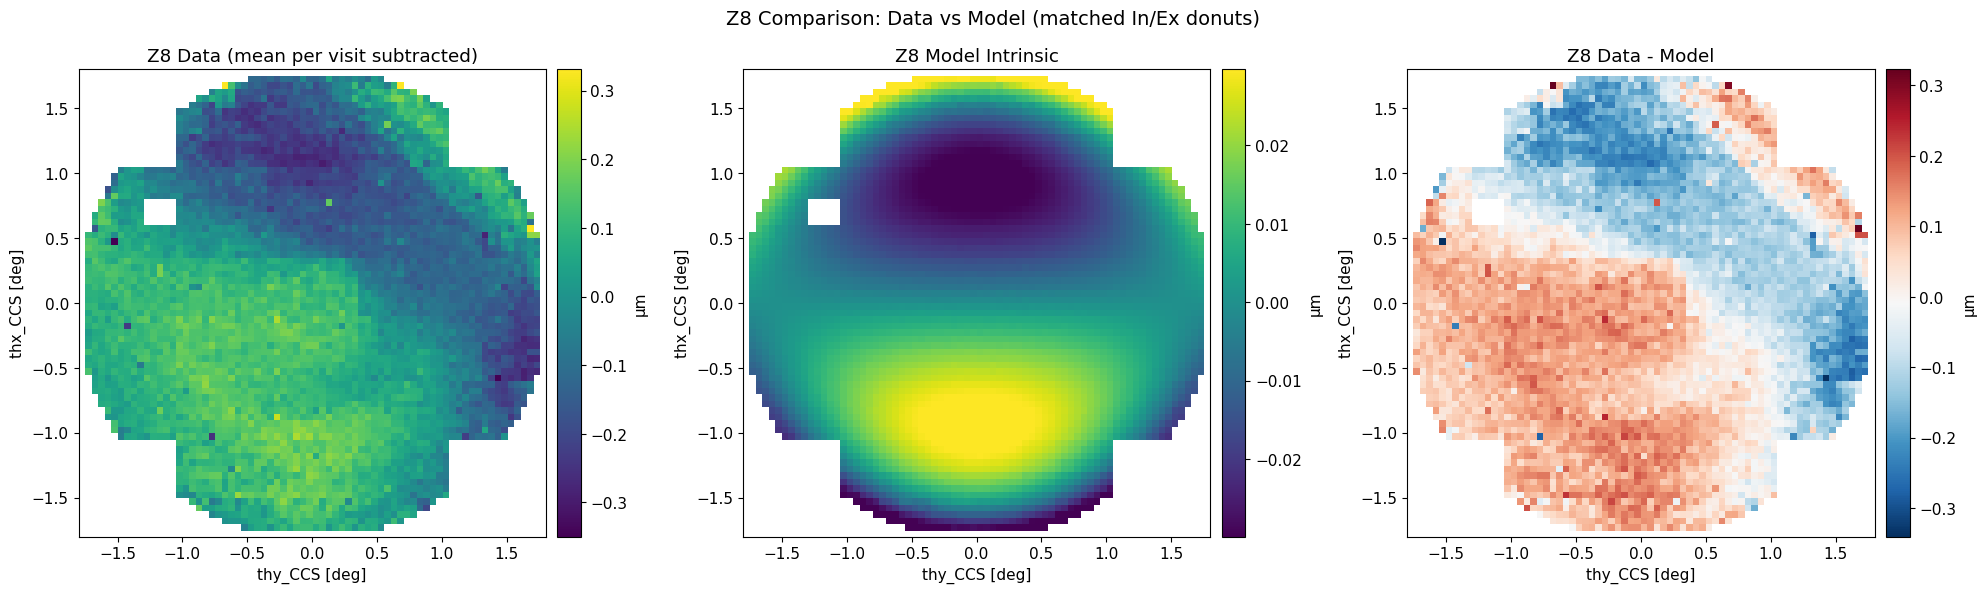


Z8 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.22
  Model:            mean=  -0.00, std=   0.02
  Residual:         mean=   0.00, std=   0.22
Saved: ./Z9_trio_comparison.png


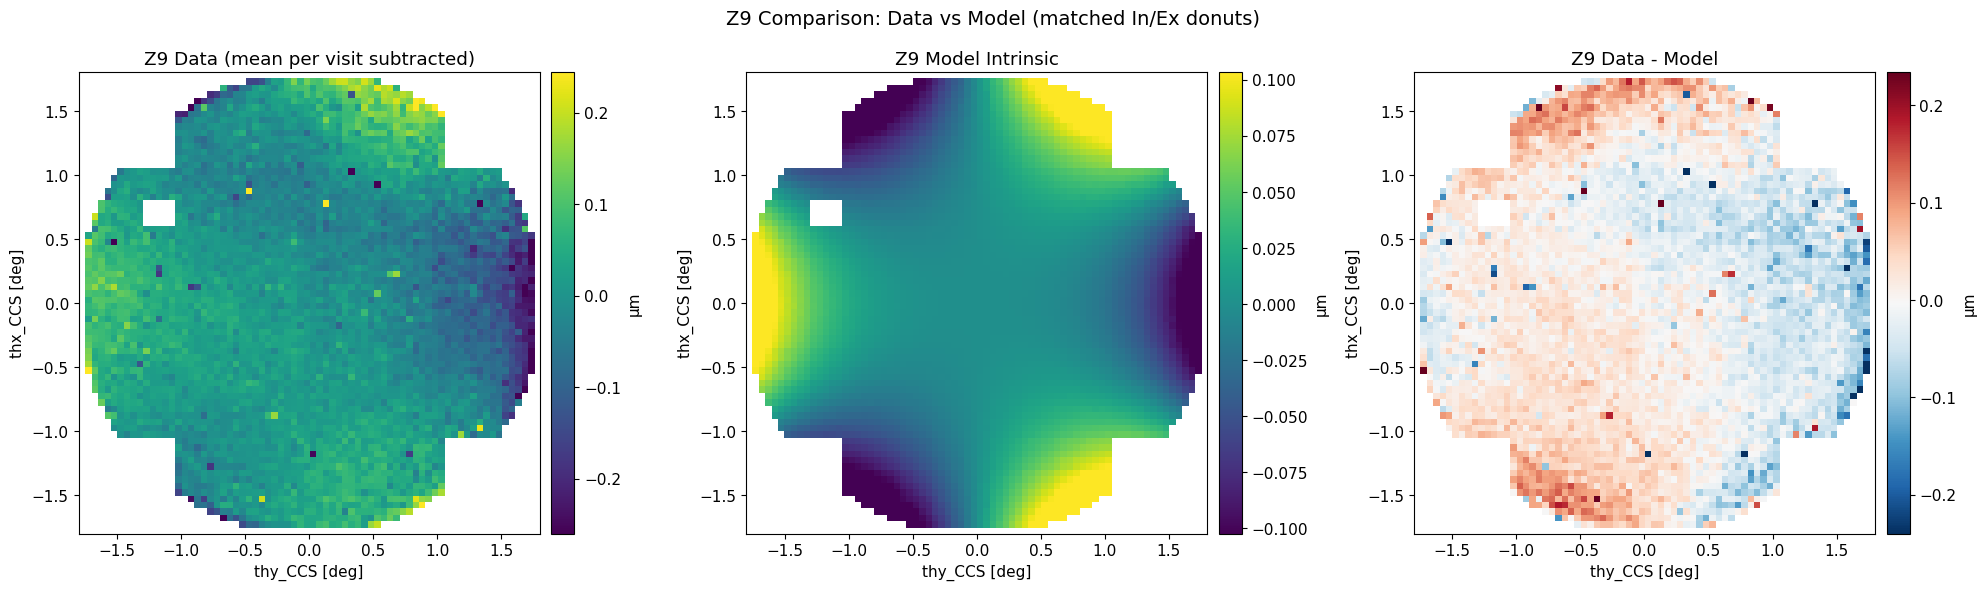


Z9 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.18
  Model:            mean=   0.00, std=   0.05
  Residual:         mean=  -0.00, std=   0.17
Saved: ./Z10_trio_comparison.png


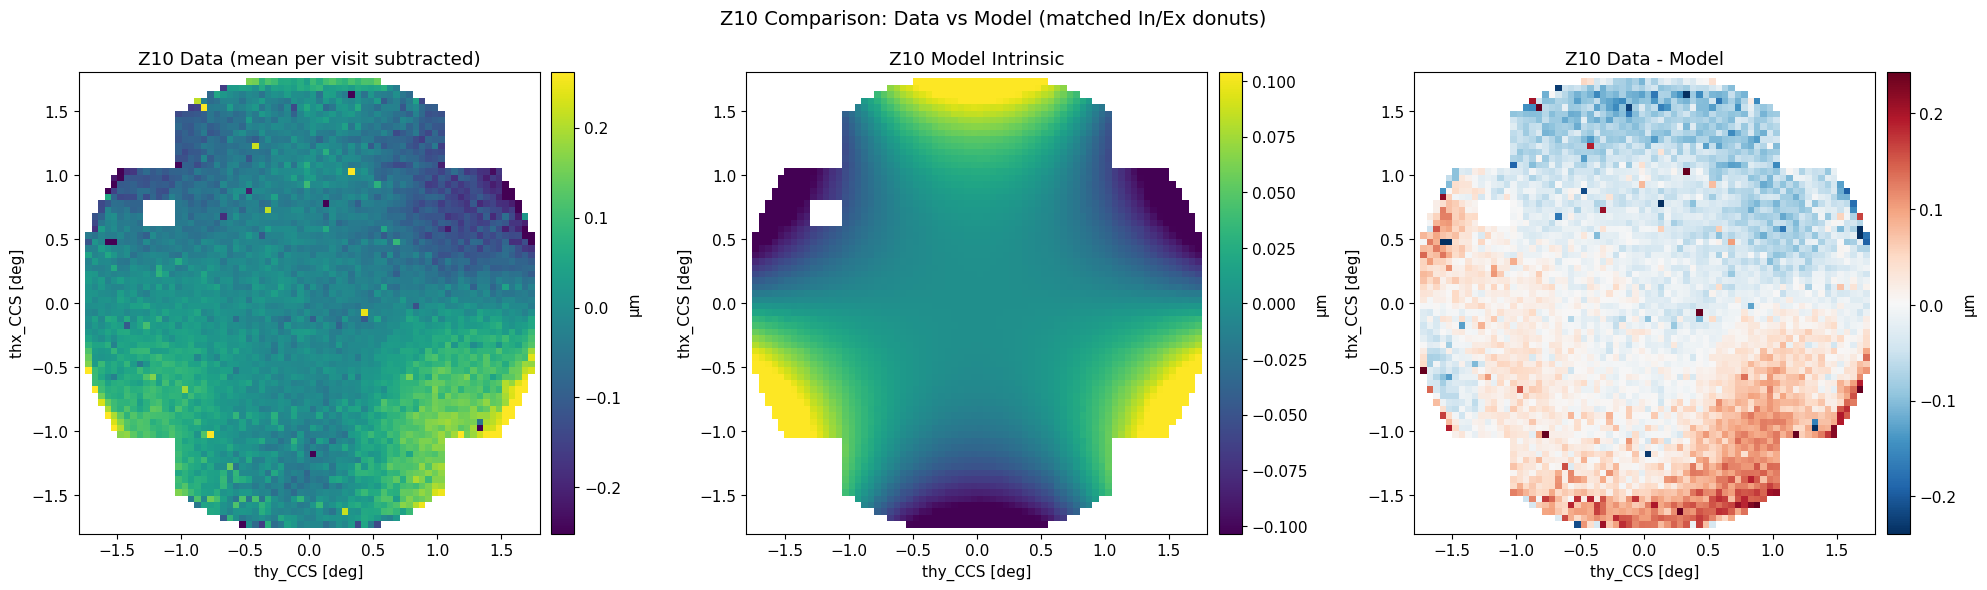


Z10 Statistics (μm):
  Data (mean-sub):  mean=  -0.00, std=   0.18
  Model:            mean=   0.00, std=   0.05
  Residual:         mean=  -0.00, std=   0.18
Saved: ./Z11_trio_comparison.png


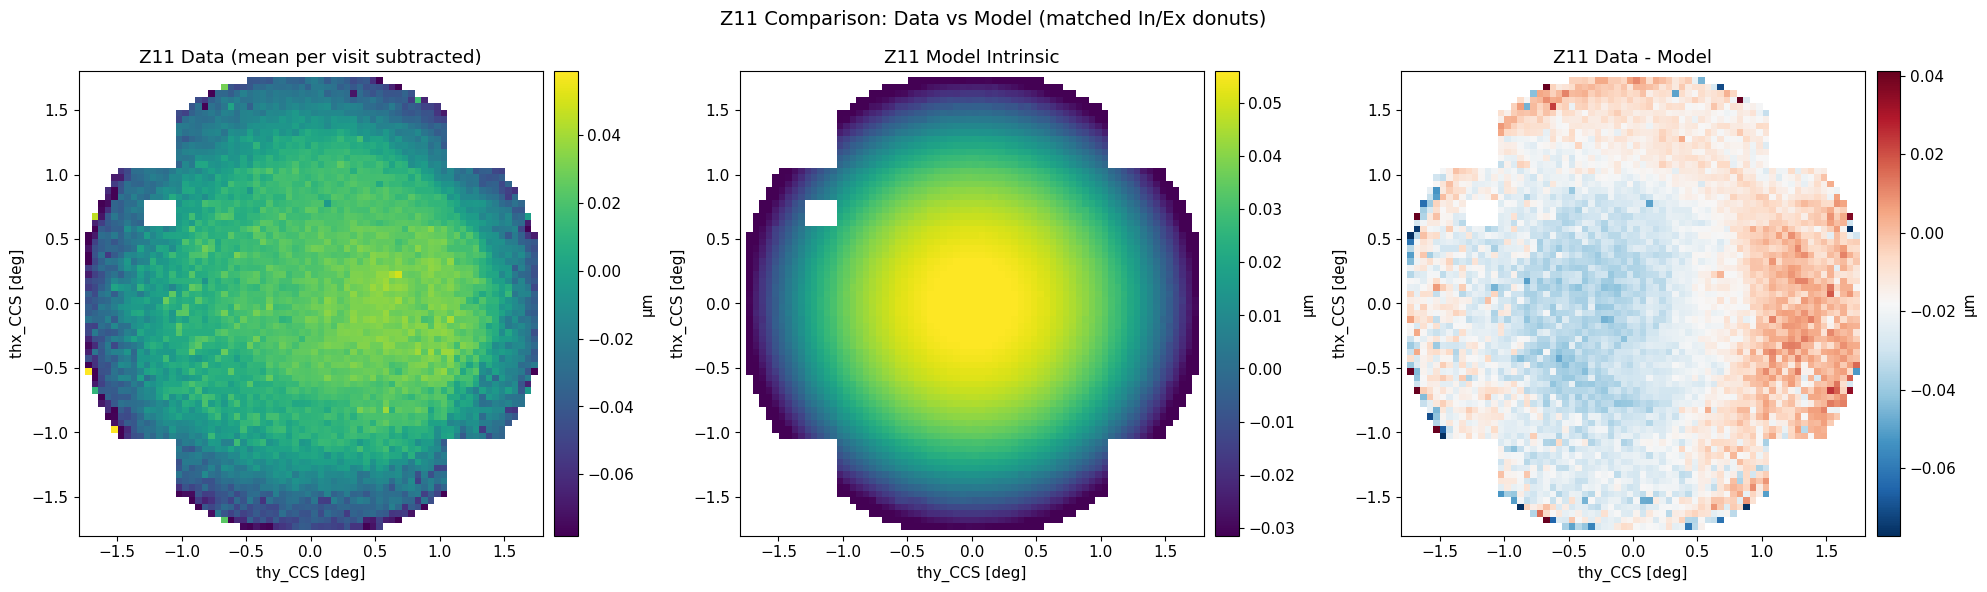


Z11 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.04
  Model:            mean=   0.02, std=   0.03
  Residual:         mean=  -0.02, std=   0.04


In [13]:
# Plot all Zernike terms
iZs_to_plot = [4, 5, 6, 7, 8, 9, 10, 11]  # First 8 Zernikes

for iZ in iZs_to_plot:
    plot_zernike_trio(aosTable_matched, iZ=iZ, plo=4.0, phi=96.0, output_dir='.')

Saved: ./Z12_trio_comparison.png


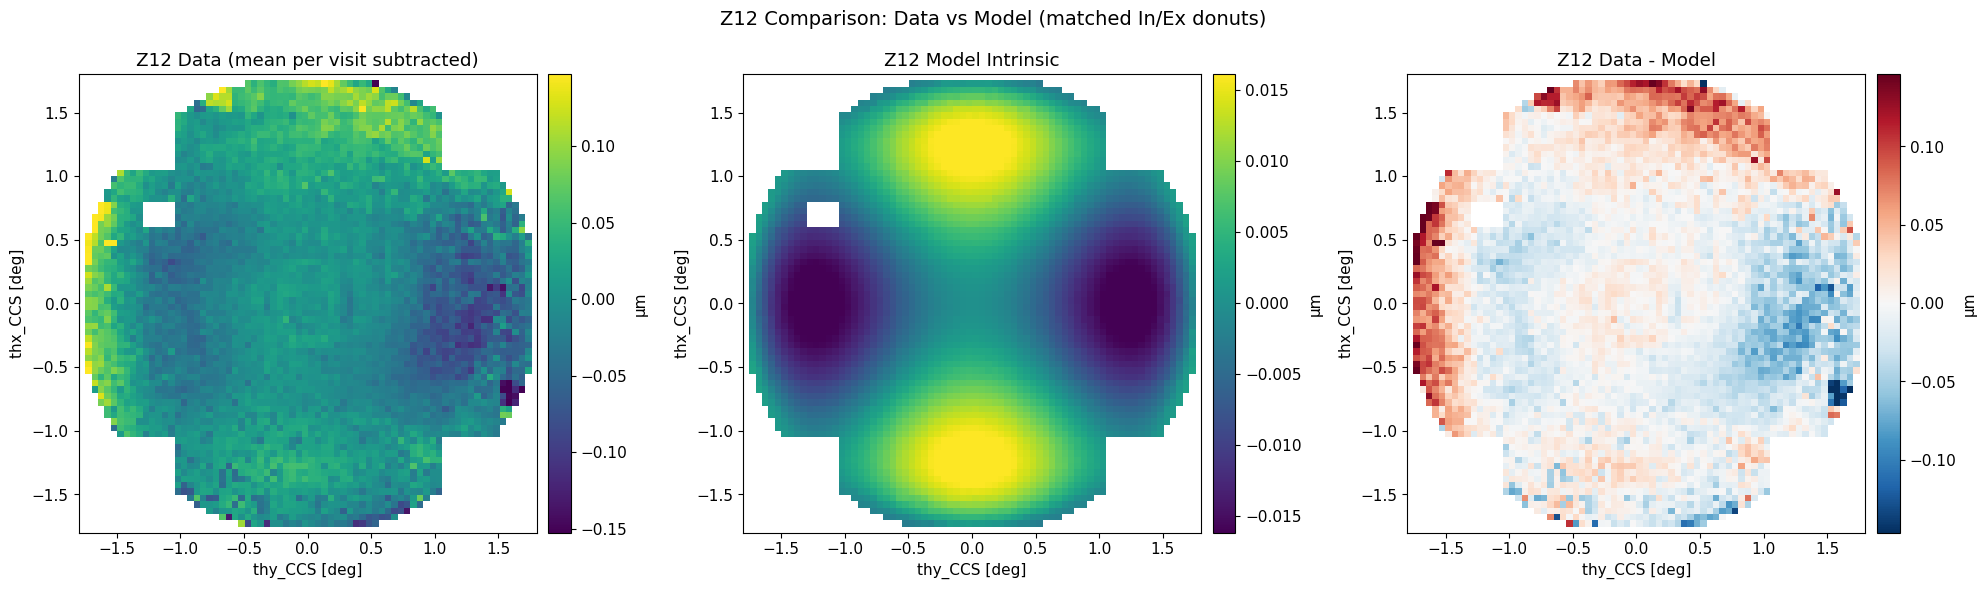


Z12 Statistics (μm):
  Data (mean-sub):  mean=  -0.00, std=   0.09
  Model:            mean=  -0.00, std=   0.01
  Residual:         mean=  -0.00, std=   0.09
Saved: ./Z13_trio_comparison.png


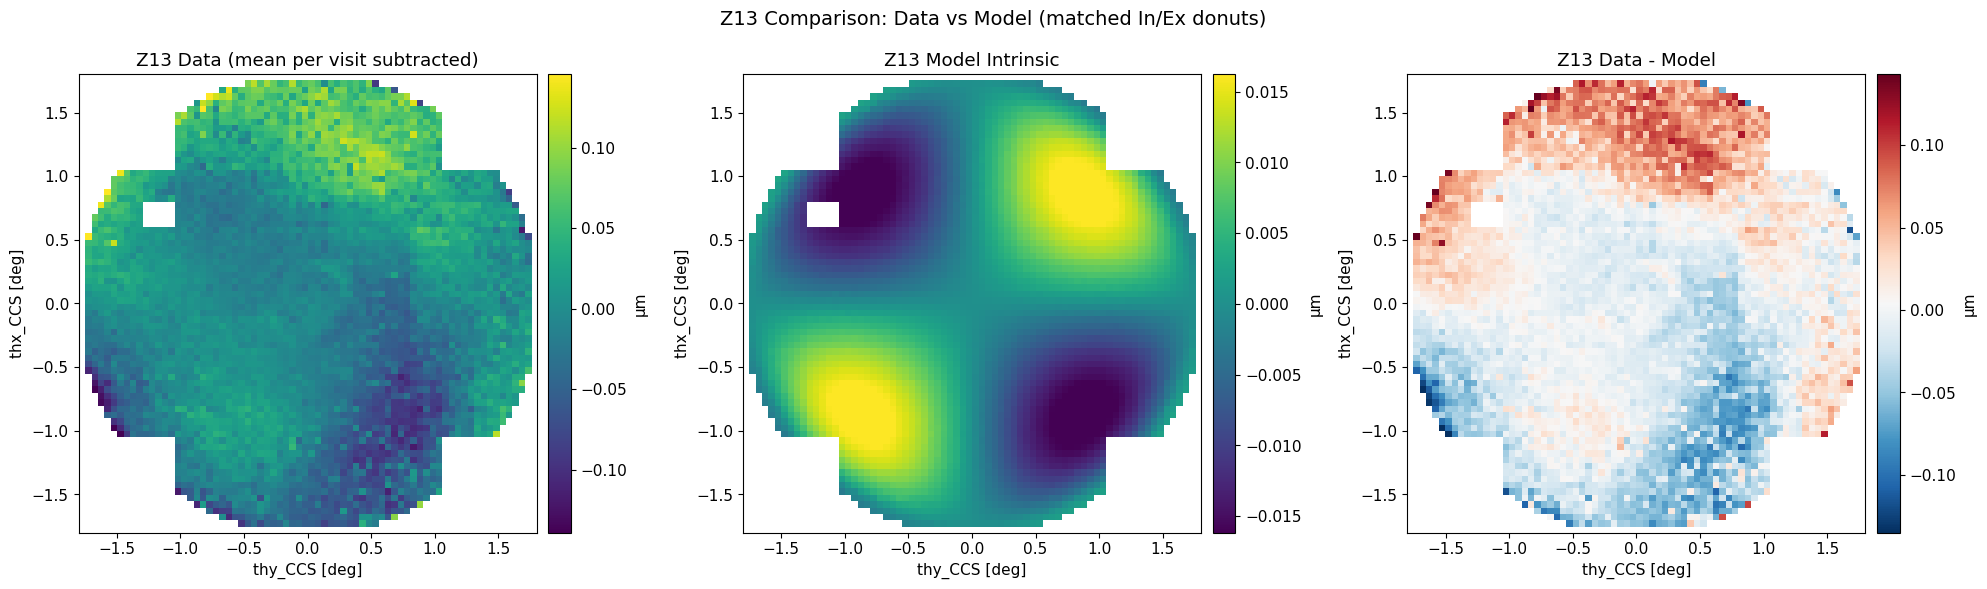


Z13 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.08
  Model:            mean=  -0.00, std=   0.01
  Residual:         mean=   0.00, std=   0.08
Saved: ./Z14_trio_comparison.png


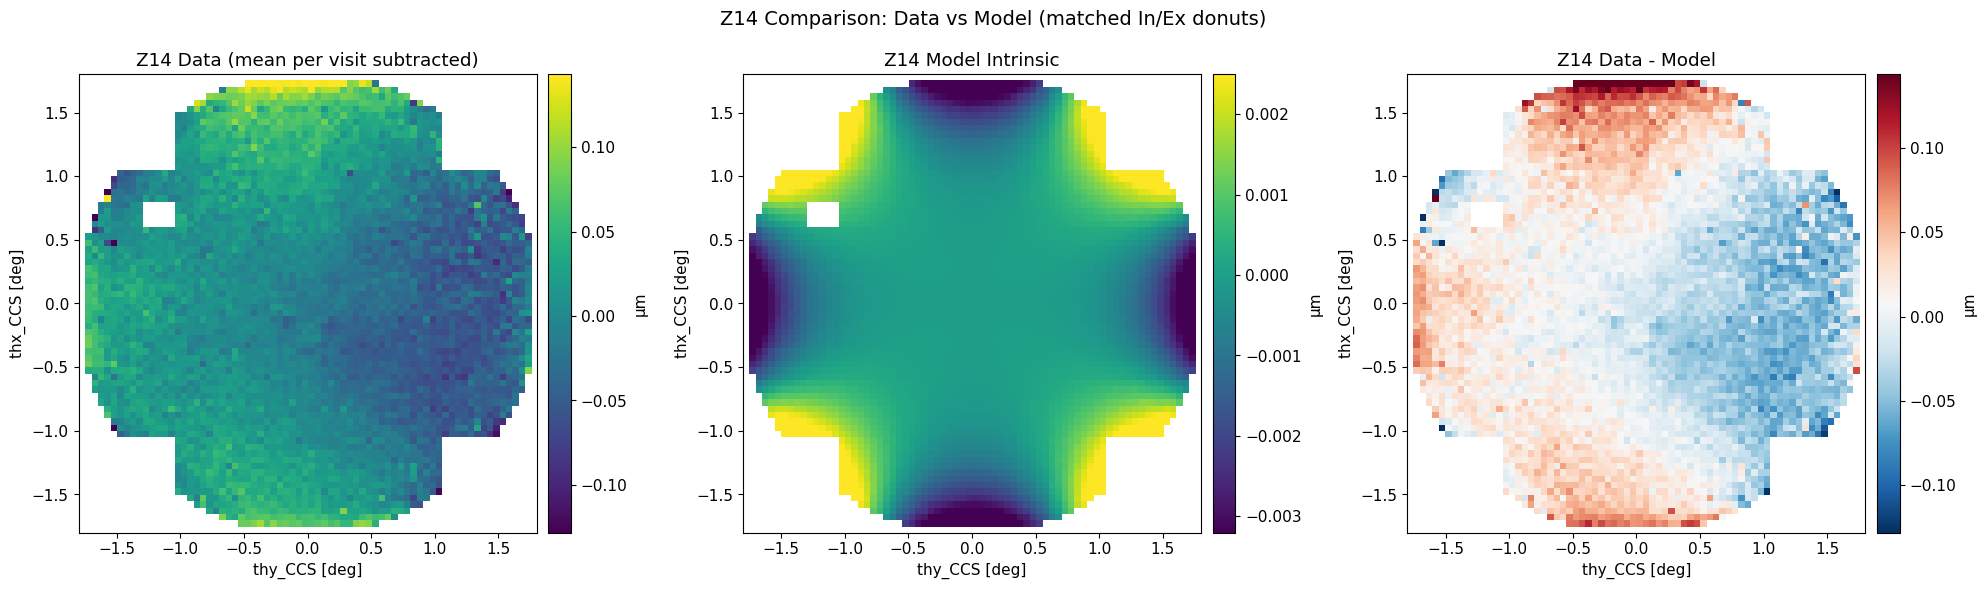


Z14 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.08
  Model:            mean=  -0.00, std=   0.00
  Residual:         mean=   0.00, std=   0.09
Saved: ./Z15_trio_comparison.png


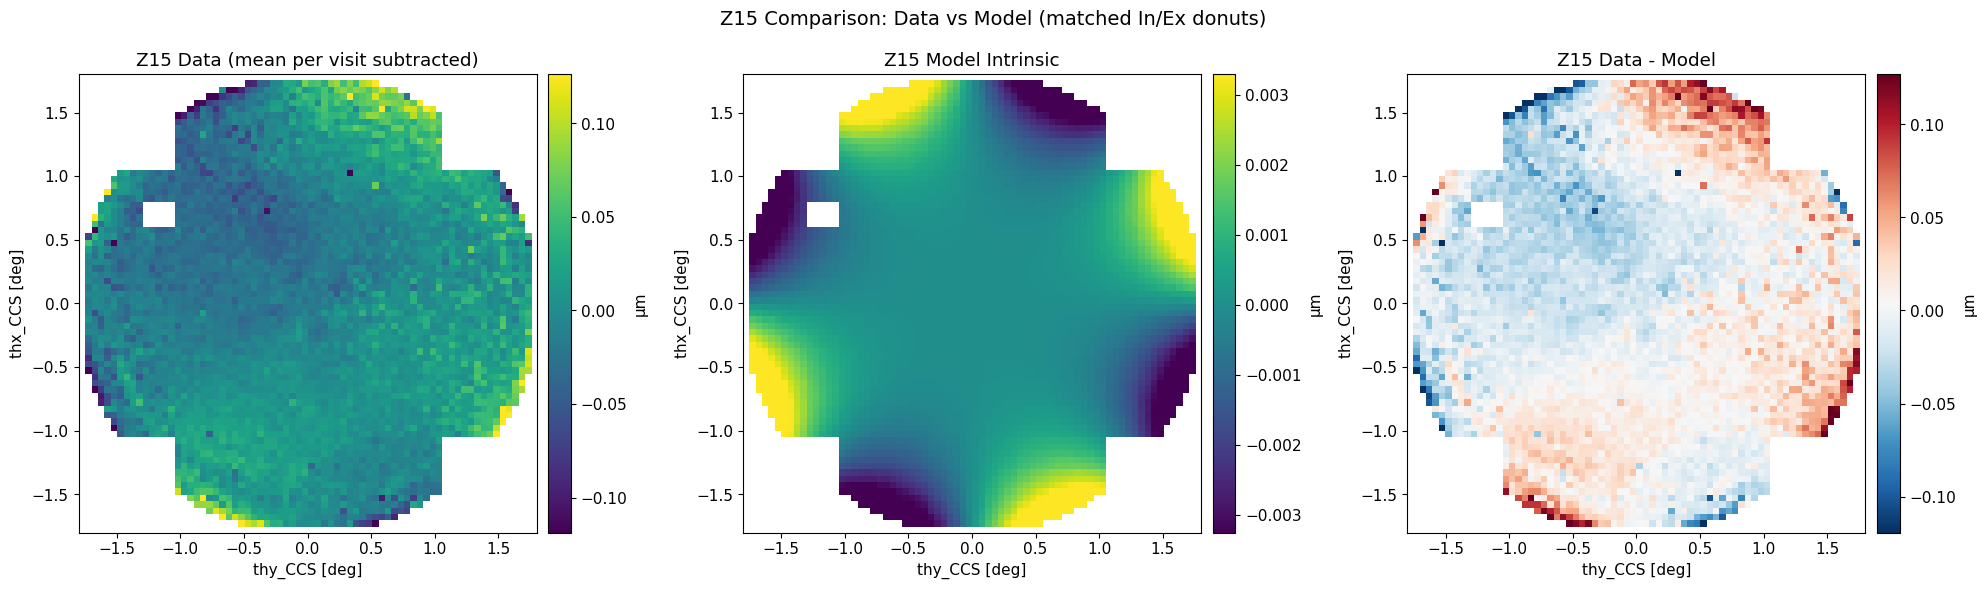


Z15 Statistics (μm):
  Data (mean-sub):  mean=  -0.00, std=   0.08
  Model:            mean=   0.00, std=   0.00
  Residual:         mean=  -0.00, std=   0.08
Saved: ./Z16_trio_comparison.png


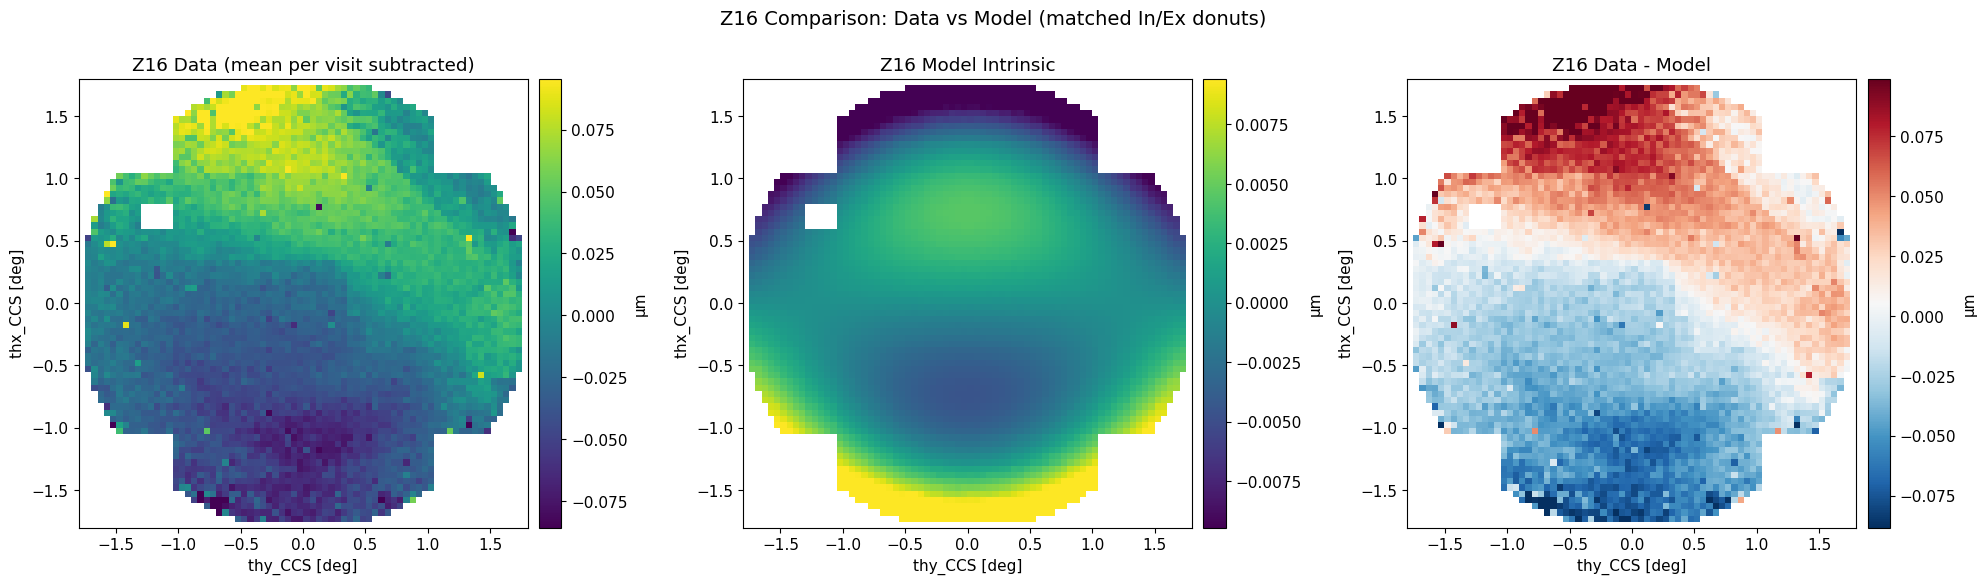


Z16 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.06
  Model:            mean=  -0.00, std=   0.00
  Residual:         mean=   0.00, std=   0.06
Saved: ./Z17_trio_comparison.png


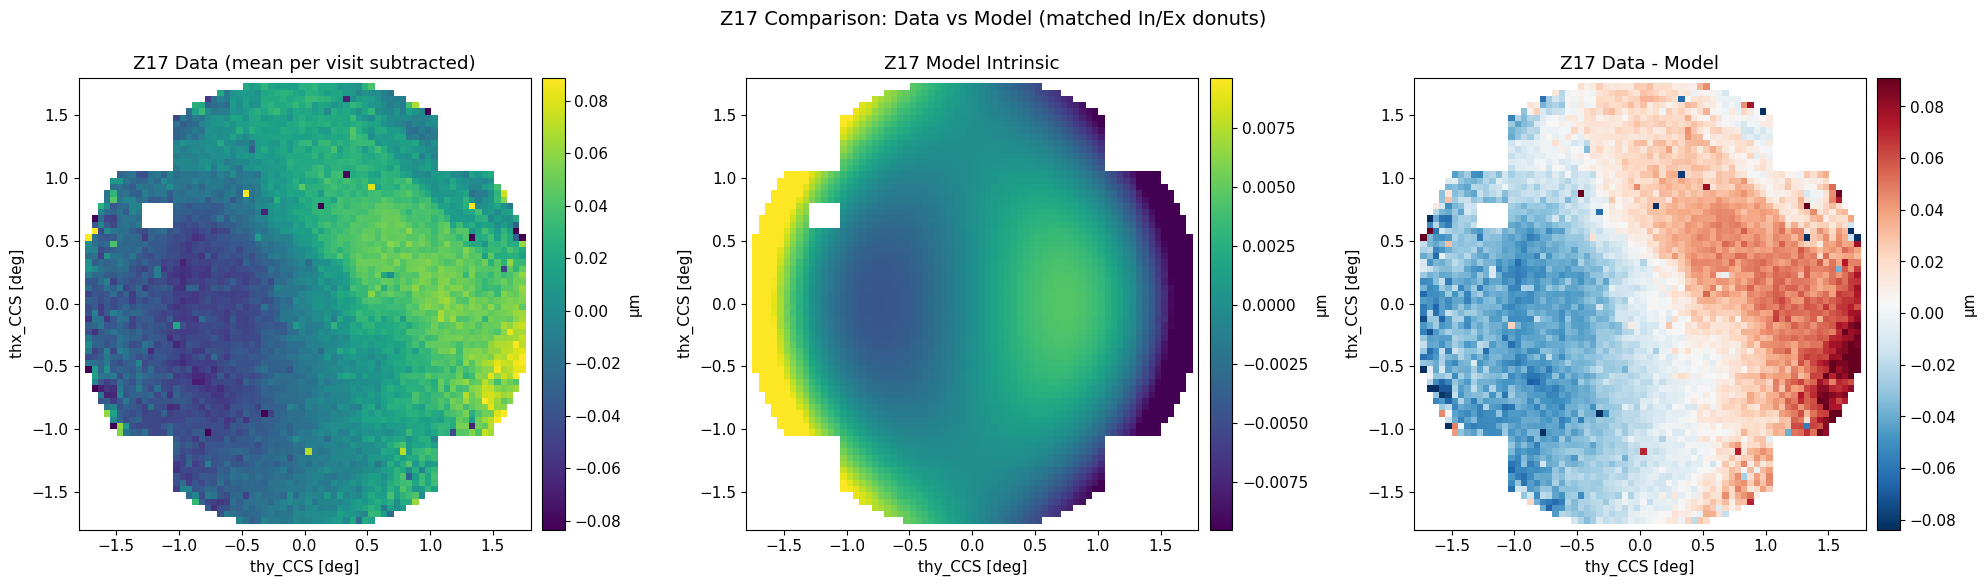


Z17 Statistics (μm):
  Data (mean-sub):  mean=  -0.00, std=   0.06
  Model:            mean=  -0.00, std=   0.00
  Residual:         mean=   0.00, std=   0.06
Saved: ./Z18_trio_comparison.png


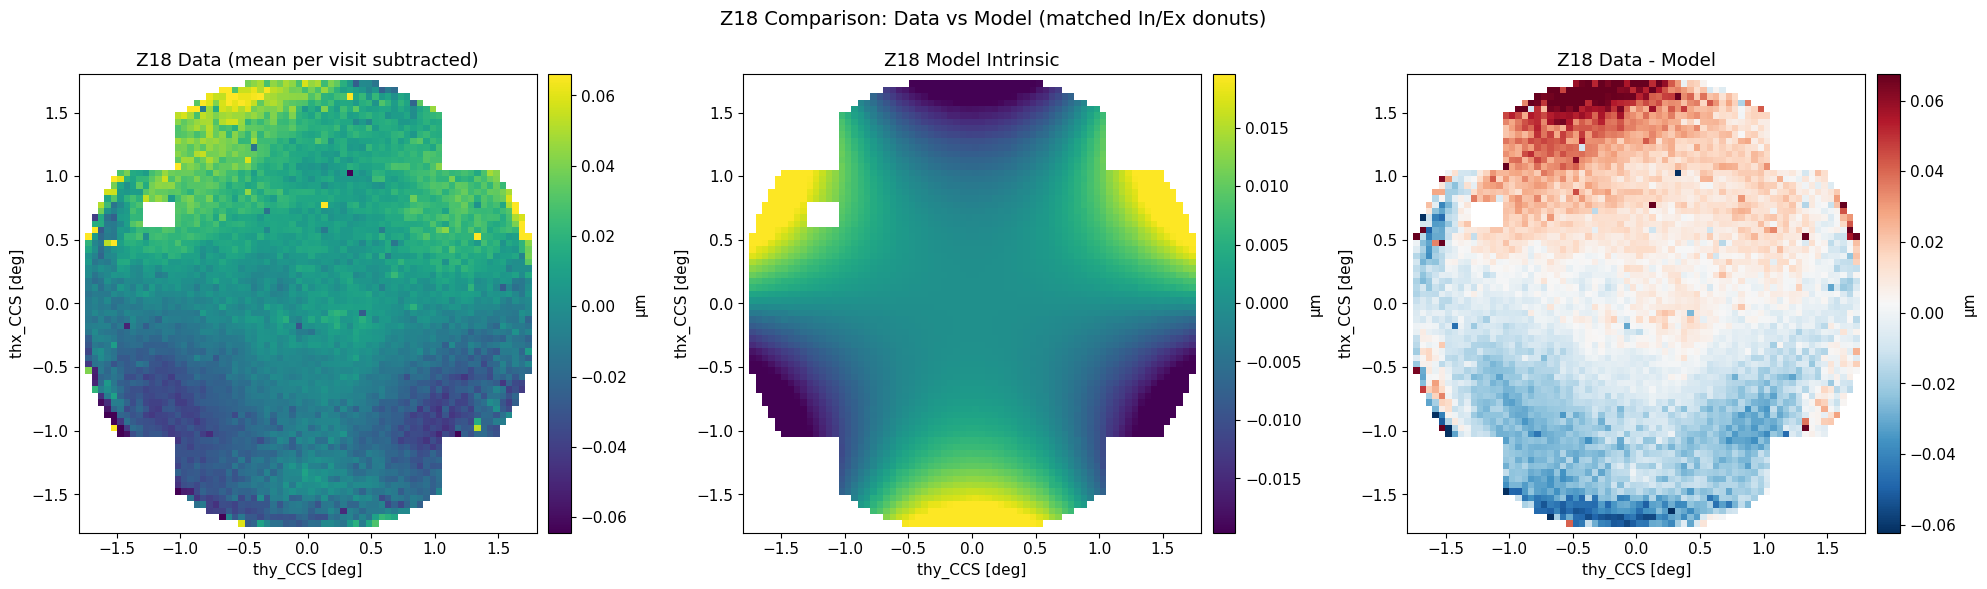


Z18 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.04
  Model:            mean=  -0.00, std=   0.01
  Residual:         mean=   0.00, std=   0.04
Saved: ./Z19_trio_comparison.png


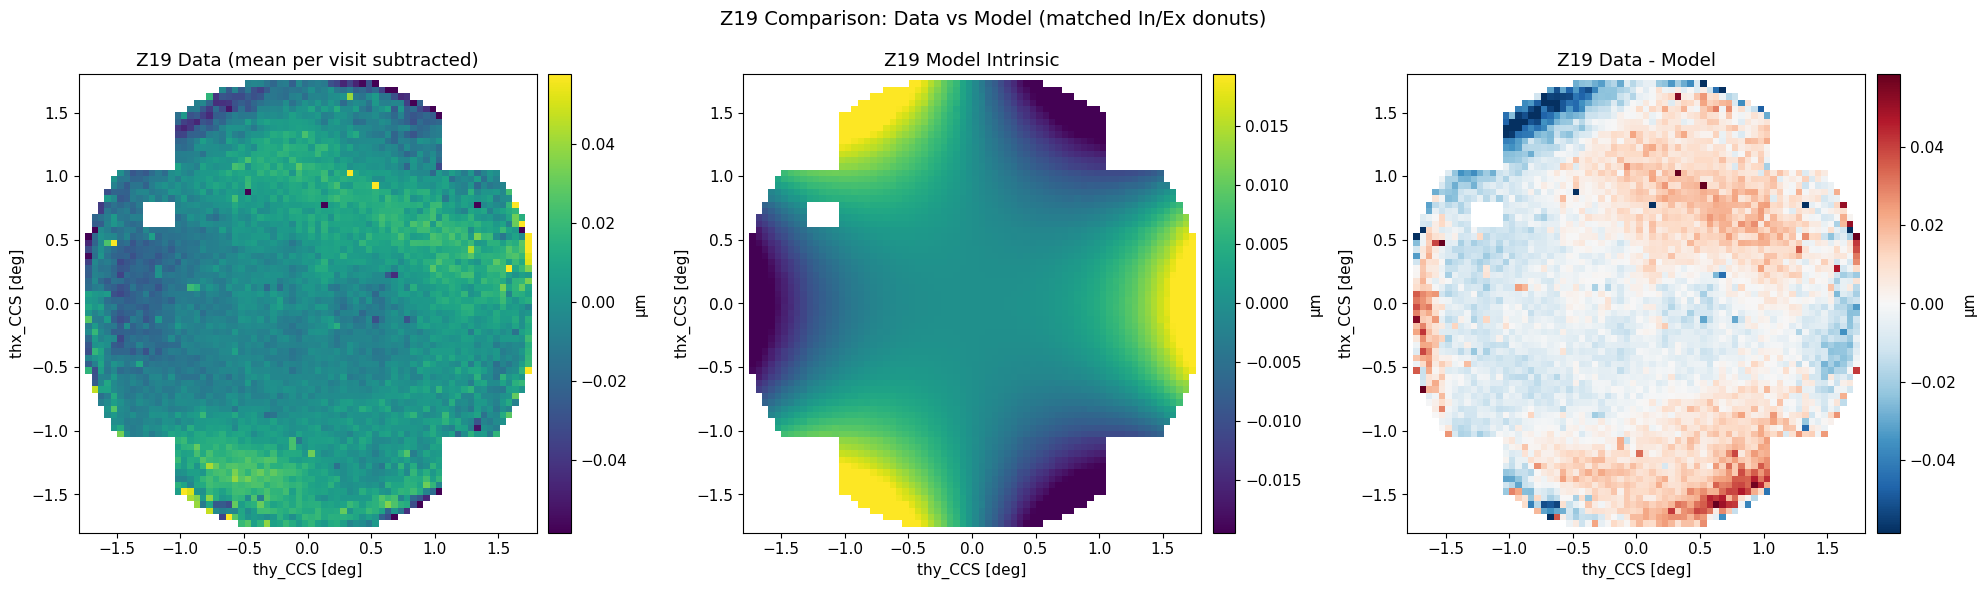


Z19 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.04
  Model:            mean=  -0.00, std=   0.01
  Residual:         mean=   0.00, std=   0.04
Saved: ./Z22_trio_comparison.png


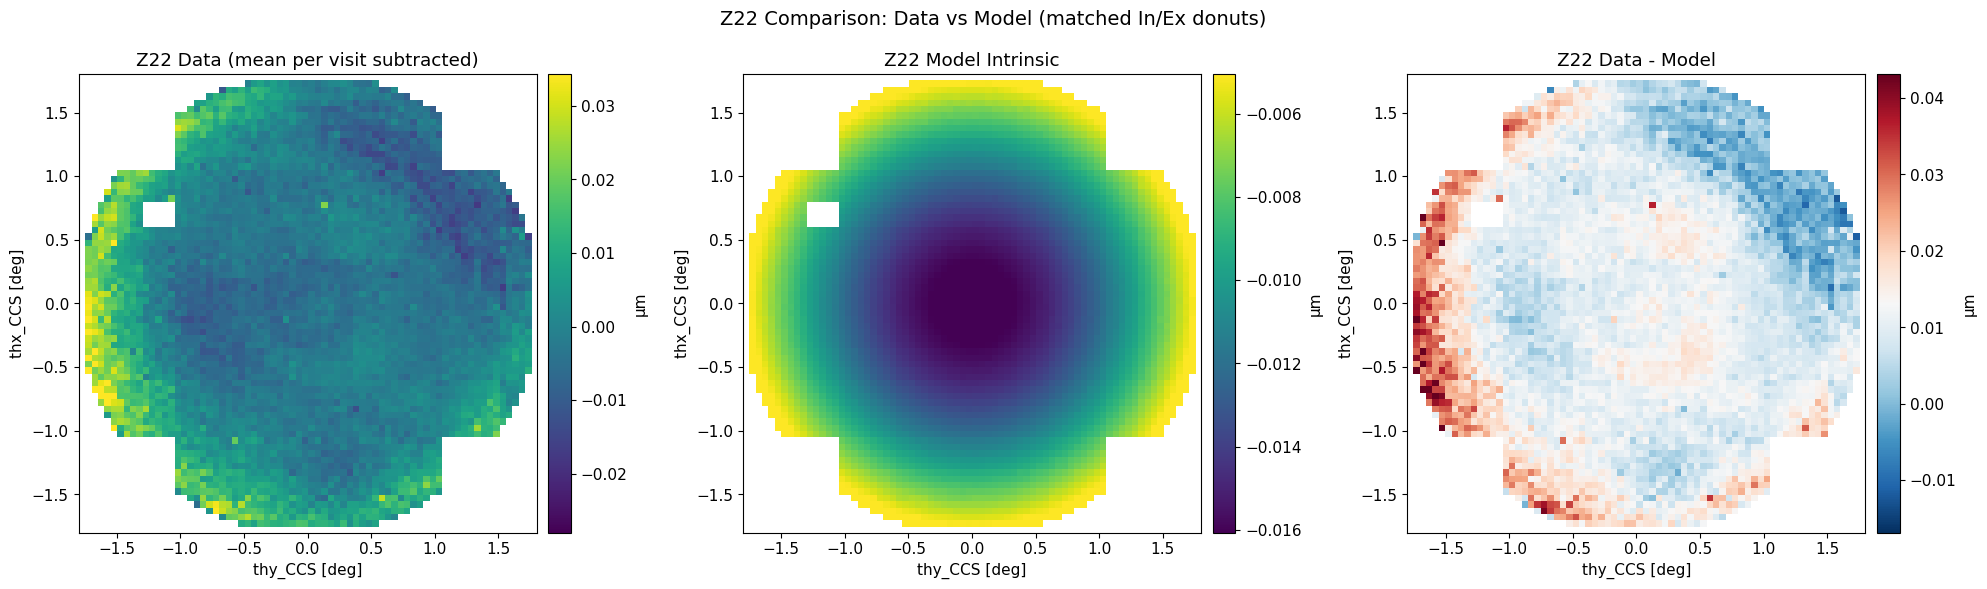


Z22 Statistics (μm):
  Data (mean-sub):  mean=   0.00, std=   0.02
  Model:            mean=  -0.01, std=   0.00
  Residual:         mean=   0.01, std=   0.02


In [14]:
# Plot all Zernike terms
iZs_to_plot = [12,13,14,15,16,17,18,19,22]  # First 8 Zernikes

for iZ in iZs_to_plot:
    plot_zernike_trio(aosTable_matched, iZ=iZ, plo=4.0, phi=96.0, output_dir='.')